本节课老师讲的是以预测买房价格为背景的线性回归，是深度学习的基础~

假设y是真实值，y1是预估值，我们可以比较   f(y,y1)=1/2 * (y-y1)²,这个叫做平方损失

收集一些数据点来决定参数值（权重或者偏差），这被称之为训练数据

## 学习率（Learning Rate）

- 定义：参数沿负梯度方向更新的步长。
- 更新公式：$\theta \leftarrow \theta - \eta \nabla J(\theta)$，其中 $\eta$ 为学习率。
- 太小：收敛慢，训练时间长。
- 太大：可能震荡甚至发散，错过最优解。
- 选择：通常从小到大尝试（0.1、0.01、0.001），或使用学习率衰减。
- 自适应优化器（如 Adam）可动态调整学习率。

In [89]:
import random
import torch
from d2l import torch as d2l

构造人造数据集
## 生成合成线性回归数据（逐句解释）

1. **定义函数** `synthetic_data(w, b, num_examples)`：接收真实权重、偏差和样本数。
2. **文档字符串**：说明生成的数据满足 `y = Xw + b + 噪声`。
3. **生成特征矩阵 X**：从标准正态分布采样，形状为 `(num_examples, len(w))`，每行一个样本，每列一个特征。
4. **计算线性部分**：矩阵乘法 `Xw` 加上偏差 `b`，得到无噪声的预测值。
5. **加入高斯噪声**：均值为0、标准差为0.01，形状与 `y` 相同，模拟真实数据误差。
6. **返回数据**：特征矩阵 `X` 和标签列向量 `y`（形状 `(num_examples, 1)`）。
7. **设置真实权重**：`true_w = [2, -3.4]`。
8. **设置真实偏差**：`true_b = 4.2`。
9. **生成数据集**：调用函数产生1000个样本，存入 `features` 和 `labels`（变量名 `labels` 有拼写错误，不影响运行）。

In [90]:
def synthetic_data(w,b,num_examples):
    "生成 y=X*w+b+噪声"
    X=torch.normal(0,1,(num_examples,len(w)))# 构建X
    y=torch.matmul(X,w)+b #矩阵乘法函数
    y=y+torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1)) #这个-1，意思是让系统自己帮你计算，而不是真的-1
true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)    

features中每一行都包含一个二维数据样本，labels中每一行都包含一个标签值--相当于X是x的某个特定值，labels是对应的y值，现在我们需要根据这个样本，来找出w和b

## 绘制散点图：features 与 labels

1. `d2l.set_figsize()`  
   - 设置图形的默认尺寸（宽、高），让图更清晰。

2. `d2l.plt.scatter(...)`  
   - 调用 Matplotlib 的 `scatter` 函数绘制散点图。

3. `features[:, 1].detach().numpy()`  
   - `features[:, 1]`：取出特征矩阵的第二列（索引为 1）作为 x 轴数据。  
   - `.detach()`：将张量从计算图中分离，返回不需要梯度的张量（防止转换 NumPy 时出错）。  
   - `.numpy()`：将 PyTorch 张量转换为 NumPy 数组，供 Matplotlib 使用。

4. `labels.detach().numpy()`  
   - 标签张量先分离计算图，再转为 NumPy 数组，作为 y 轴数据。

5. `1`（第三个参数）  
   - 散点图中点的大小，1 表示较小的点。

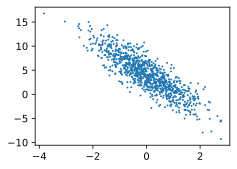

In [91]:
d2l.set_figsize()
d2l.plt.scatter(features[:,(1)].detach().numpy(),labels.detach().numpy(),1) #detach()是安全写法，有没有都行

定义一个data_iter函数，该函数接收批量大小，特征矩阵和标签向量作为输入，生成大小为batch_size的小批量

## 数据迭代器：逐句解释

- `def data_iter(batch_size, features, labels):`  
  定义生成器函数，用于按批次返回特征和标签。

- `num_examples = len(features)`  
  获取样本总数。

- `indices = list(range(num_examples))`  
  生成从 0 到样本数-1 的索引列表。

- `random.shuffle(indices)`  
  原地随机打乱索引顺序，实现每个 epoch 的随机读取。

- `for i in range(0, num_examples, batch_size):`  
  按 `batch_size` 步长遍历索引。

- `batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)])`  
  截取当前批次的索引（防止最后一组越界），并转为张量。

- `yield features[batch_indices], labels[batch_indices]`  
  返回当前批次的特征和标签。`yield` 使函数成为生成器，每次调用只产生一批，节省内存。

- `batch_size = 10`  
  设置批大小为 10。

- `for x, y in data_iter(batch_size, features, labels):`  
  从生成器中迭代获取批次。

- `print(x, '\n', y)`  
  打印特征和标签。

- `break`  
  只查看第一个批次后退出循环，避免打印全部数据。

In [92]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    #样本随机读取，没有顺序
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]
batch_size=10
for x,y in data_iter(batch_size,features,labels):
    print(x,'\n',y)
    break

tensor([[-0.1248,  1.7602],
        [ 0.3677, -0.4891],
        [ 1.0612, -0.3470],
        [-0.3520,  0.7643],
        [ 0.0686,  0.4686],
        [ 0.2113,  0.6670],
        [-0.5932,  0.9334],
        [ 1.7915, -0.0199],
        [ 1.1633,  1.2539],
        [ 1.4007,  1.2588]]) 
 tensor([[-2.0262],
        [ 6.5982],
        [ 7.4965],
        [ 0.8943],
        [ 2.7337],
        [ 2.3505],
        [-0.1547],
        [ 7.8507],
        [ 2.2739],
        [ 2.7249]])


定义初始化参数，其中w定义为形状为（2，1）矩阵：两个参数嘛
b的初始值作为1

In [93]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

定义模型

In [94]:
def linreg(x,w,b):
    return torch.matmul(x,w) + b

定义损失函数

In [95]:
def squared_loss(y_hat, y):#y_hat预测值，y真实值
    '''均方损失'''
    return (y_hat-y.reshape(y_hat.shape))**2/2

定义优化算法
## 小批量随机梯度下降函数（sgd）

- `def sgd(params, lr, batch_size):`  
  定义优化函数，参数为模型参数列表、学习率、批量大小。

- `'''小批量随机梯度下降'''`  
  文档字符串，说明函数功能。

- `with torch.no_grad():`  
  进入无梯度计算上下文，在此代码块内的张量操作不会被记录到计算图中，避免更新参数时产生梯度。

- `for param in params:`  
  遍历模型中的每个参数张量（如权重和偏置）。

- `param -= lr * param.grad / batch_size`  
  该行执行参数更新：参数沿着负梯度方向移动，步长为 `学习率 × 梯度 / 批量大小`。  
  除以 `batch_size` 是因为损失通常是批量样本损失的平均值。

- `param.grad.zero_()`  
  将当前参数的梯度清零，防止下一次反向传播时梯度累加，导致更新错误。

In [96]:
def sgd(params, lr, batch_size):
    '''小批量随机梯度下降'''
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

## 线性回归训练循环（逐句解释）

1. `lr = 0.03`：设置学习率，控制参数更新步长。
2. `num_epochs = 3`：设置训练轮数，整个数据集遍历 3 次。
3. `net = linreg`：将线性回归模型函数赋值给 `net`。
4. `loss = squared_loss`：将平方损失函数赋值给 `loss`。
5. `for epoch in range(num_epochs):`：外层循环，每轮遍历一次完整数据集。
6. `for x, y in data_iter(batch_size, features, labels):`：内层循环，按批次取出特征和标签。
7. `l = loss(net(x, w, b), y)`：计算当前批量样本的损失，形状为 `(batch_size, 1)`。
8. `l.sum().backward()`：将批量损失求和后反向传播，自动求参数梯度。
9. `sgd([w, b], lr, batch_size)`：调用小批量随机梯度下降，更新 `w` 和 `b`。
10. `with torch.no_grad():`：进入评估模式，不追踪梯度。
11. `train_l = loss(net(features, w, b), labels)`：用全量数据计算整体损失。
12. `print(...)`：打印当前 epoch 的平均损失，格式为浮点数。

In [97]:
lr=0.05
num_epochs=3 # 训练轮数
net=linreg
loss=squared_loss
for epoch in range(num_epochs):
    for x, y in data_iter(batch_size, features, labels):
        l = loss(net(x, w, b), y)   # x,y的小批量损失
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch+1}, loss={float(train_l.mean()):f}')

epoch 1, loss=0.000841
epoch 2, loss=0.000052
epoch 3, loss=0.000052


In [98]:
print(f'w的估计误差：{true_w-w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b-b}')

w的估计误差：tensor([-4.3392e-05,  2.5558e-04], grad_fn=<SubBackward0>)
b的估计误差：tensor([-0.0005], grad_fn=<RsubBackward1>)
